In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\sindh\OneDrive\Desktop\customer-churn-prediction\venv\Scripts\python.exe
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [19]:
import mlflow
import mlflow.sklearn
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

In [20]:
print("Imports Successful!")

Imports Successful!


In [21]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    ),
}

In [22]:
mlflow.set_experiment("churn_prediction")

<Experiment: artifact_location='file:///c:/Users/sindh/OneDrive/Desktop/customer-churn-prediction/notebooks/mlruns/290398461798858810', creation_time=1783425059749, experiment_id='290398461798858810', last_update_time=1783425059749, lifecycle_stage='active', name='churn_prediction', tags={}>

In [23]:
for name, model in models.items():

    with mlflow.start_run(run_name=name):

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics = {
            "roc_auc": roc_auc_score(y_test, y_prob),
            "f1": f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
        }

        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)

        mlflow.sklearn.log_model(
            model,
            artifact_path="model"
        )

        print(f"{name}: {metrics}")

ValueError: could not convert string to float: '4950-BDEUX'

In [24]:
import pandas as pd
import os
import sys

project_root = os.path.abspath("..")
sys.path.append(project_root)

from src.feature_engineering import engineer_features

In [25]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = engineer_features(df)

In [26]:
print(df.shape)

print(df.columns.tolist())

print("AvgMonthlySpend" in df.columns)

(7043, 30)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend', 'HasMultiServices', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_mid', 'TenureGroup_mature', 'TenureGroup_loyal']
True


In [27]:
from src.feature_engineering import engineer_features

print(engineer_features)

<function engineer_features at 0x0000019A13A34CA0>


In [28]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend', 'HasMultiServices', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_mid', 'TenureGroup_mature', 'TenureGroup_loyal']


In [29]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print(X_train.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'HasMultiServices', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_mid', 'TenureGroup_mature', 'TenureGroup_loyal']


In [32]:
print(X_train.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'HasMultiServices', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_mid', 'TenureGroup_mature', 'TenureGroup_loyal']


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8278, 29)
(1409, 29)
(8278,)
(1409,)


In [13]:
mlflow.set_experiment("churn_prediction")

<Experiment: artifact_location='file:///c:/Users/sindh/OneDrive/Desktop/customer-churn-prediction/notebooks/mlruns/290398461798858810', creation_time=1783425059749, experiment_id='290398461798858810', last_update_time=1783425059749, lifecycle_stage='active', name='churn_prediction', tags={}>

In [14]:
for name, model in models.items():

    with mlflow.start_run(run_name=name):

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics = {
            "roc_auc": roc_auc_score(y_test, y_prob),
            "f1": f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
        }

        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)

        mlflow.sklearn.log_model(
            model,
            artifact_path="model"
        )

        print(f"{name}: {metrics}")

RandomForest: {'roc_auc': 0.8337027564649049, 'f1': 0.6121495327102804, 'precision': 0.5435684647302904, 'recall': 0.7005347593582888}


c:\Users\sindh\OneDrive\Desktop\customer-churn-prediction\venv\lib\site-packages\xgboost\data.py:335: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
c:\Users\sindh\OneDrive\Desktop\customer-churn-prediction\venv\lib\site-packages\xgboost\data.py:338: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  is_categorical_dtype(dtype) or is_pa_ext_categorical_dtype(dtype)
c:\Users\sindh\OneDrive\Desktop\customer-churn-prediction\venv\lib\site-packages\xgboost\data.py:384: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype):
c:\Users\sindh\OneDrive\Desktop\customer-churn-prediction\venv\lib\site-packages\xgboost\data.py:359: FutureWarning: is_categorical_dtype is deprecated and will

XGBoost: {'roc_auc': 0.8274535637706992, 'f1': 0.5830164765525983, 'precision': 0.5542168674698795, 'recall': 0.6149732620320856}


In [15]:
import joblib

best_model = models["RandomForest"]

joblib.dump(best_model, "../models/random_forest_churn.pkl")

print("Model saved successfully!")

Model saved successfully!


In [33]:
import joblib

# Save the feature names used to train the model
joblib.dump(
    X_train.columns.tolist(),
    "../models/feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [16]:
import shap
import joblib
import matplotlib.pyplot as plt

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [17]:
import shap
print(shap.__version__)

0.43.0


In [18]:
model = joblib.load("../models/random_forest_churn.pkl")

In [19]:
explainer = shap.TreeExplainer(model)

In [20]:
shap_values = explainer.shap_values(X_test)

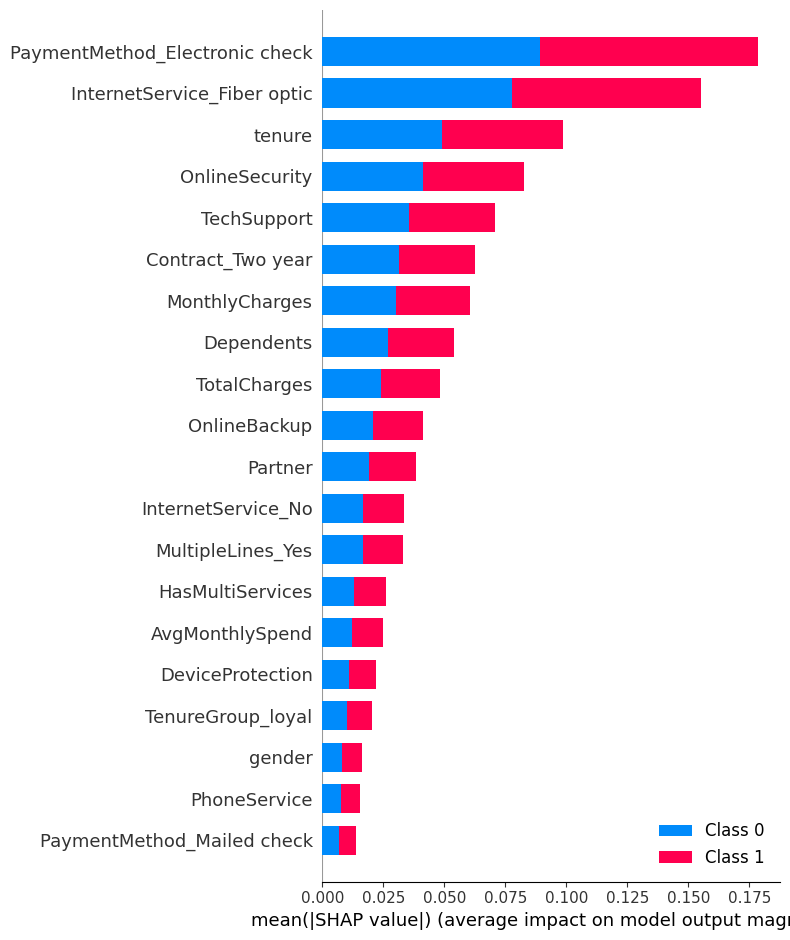

In [21]:
shap.summary_plot(shap_values, X_test)

In [22]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[0]).

In [23]:
import shap
print(shap.__version__)

0.43.0


In [24]:
print(type(shap_values))

<class 'list'>


In [25]:
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
[0.50019993 0.49980007]


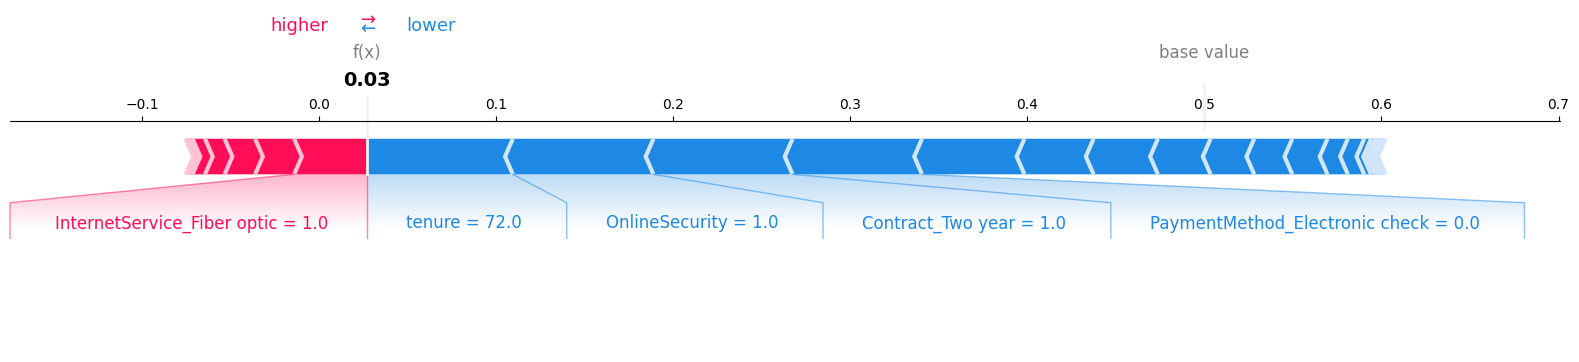

In [26]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0],
    X_test.iloc[0],
    matplotlib=True
)